# Data Inventory


## Setup & Helper Functions

This cell imports essential Python libraries (os, re, pathlib, collections, pandas, seaborn, matplotlib) and defines global constants used throughout the inventory analysis. Key configurations include:

- **Data root path**: points to the `primary_studies` directory at the repo level
- **File types**: targets common tabular formats (CSV, Excel, Parquet)
- **Stage filter**: scopes the inventory to a specific processing stage (default: `derivative`)
- **Column keyword lists**: defines fuzzy-matching rules to identify soil organic matter (SOM), bulk density (BD), and geographic area columns across heterogeneous datasets

In [1]:
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data root (repo-level data folder)
DATA_ROOT = Path("../../../../data/primary_studies")
DATA_EXTENSIONS = {".csv", ".xlsx", ".xls", ".parquet"}
STAGES = {"original", "derivative", "intermediate"}
TARGET_STAGE = "derivative"  # change if needed
# SOM-like column keywords (used for fuzzy matching)
SOM_KEYWORDS = ["soil", "organic", "matter", "carbon", "som", "soc", "fraction"]
SOM_BAD_KEYWORDS = [
    "method",
    "flag",
    "qc",
    "unit",
    "note",
    "comment",
    "id",
    "type",
    "carbonate",
    "carbonates",
    "inorganic",
]
SOM_PREFERRED = ["fraction_carbon", "fraction carbon", "soil_organic_matter", "soil organic matter", "som", "soc"]

# Column candidates
SOM_CANDIDATES = [
    "soil organic matter",
    "soil_organic_matter",
    "som",
    "organic_matter",
    "om",
    "soil organic carbon",
    "soil_organic_carbon",
    "soc",
    "organic_carbon",
    "fraction_carbon",
]
BD_CANDIDATES = ["bulk density", "bulk_density", "bd", "dry_bulk_density"]
AREA_CANDIDATES = ["area", "region", "site", "location", "loc", "state", "province", "country", "biome"]

# Optional: set if you have a standard region list to compare
EXPECTED_REGIONS = []  # e.g., ['africa','asia','europe','north america','south america','oceania','antarctica']

print(f"Targeting Folder: {DATA_ROOT.resolve()}")

Targeting Folder: /Users/delphine/Desktop/CCN-Data-Library/data/primary_studies


This cell defines the core utility functions used to scan and interpret dataset files. Since column names vary across studies (e.g. `"SOM"`, `"soil_organic_matter"`, `"fraction_carbon"`), these functions standardize column names and use a scoring system to identify the most likely match for key variables like SOM and bulk density. A file parsing function is also defined to extract structured metadata — study ID, processing stage, and file category — from each file's path, so the inventory knows what each file represents and where it fits in the data pipeline. These functions serve as building blocks used by the inventory scan in the cells below.


In [2]:
def normalize_col(col):
    return re.sub(r"[^a-z0-9]+", "_", str(col).lower()).strip("_")


def score_column(name, keywords, bad_keywords=None, preferred=None):
    n = normalize_col(name)
    score = 0
    for kw in keywords:
        if kw in n:
            score += 1
    if preferred:
        for p in preferred:
            if normalize_col(p) == n:
                score += 5
    if bad_keywords:
        for bk in bad_keywords:
            if bk in n:
                score -= 3
    # prefer shorter names if tie
    score -= len(n) * 0.001
    return score


def find_best_column(columns, candidates=None, keywords=None, bad_keywords=None, preferred=None, numeric_only=False):
    # exact/candidate matching if provided
    if candidates:
        normalized = {c: normalize_col(c) for c in columns}
        for cand in candidates:
            cand_n = normalize_col(cand)
            for raw, norm in normalized.items():
                if cand_n == norm or cand_n in norm:
                    return raw

    # exact preferred match (e.g., fraction_carbon) if present
    if preferred:
        pref_norm = [normalize_col(p) for p in preferred]
        for c in columns:
            if normalize_col(c) in pref_norm:
                return c

    # keyword scoring fallback
    if keywords:
        scored = []
        for c in columns:
            score = score_column(c, keywords, bad_keywords=bad_keywords, preferred=preferred)
            scored.append((c, score))
        scored = [s for s in scored if s[1] > 0]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[0][0] if scored else None

    return None


def parse_file_info(file_path):
    path_obj = Path(file_path)
    if path_obj.suffix.lower() not in DATA_EXTENSIONS:
        return None

    try:
        relative_path = path_obj.relative_to(DATA_ROOT)
        parts = relative_path.parts
        if len(parts) != 3:
            return None
        study_id = parts[0]
        stage = parts[1].lower()
        if stage not in STAGES:
            return None
    except ValueError:
        return None

    clean_name = path_obj.stem
    if clean_name.lower().startswith(study_id.lower()):
        category = clean_name[len(study_id) :].lstrip("_").lower()
    else:
        category = "raw_source_file"

    return {
        "path": str(path_obj),
        "filename": path_obj.name,
        "study_id": study_id,
        "stage": stage,
        "category": category,
        "ext": path_obj.suffix,
    }

## File Inventory & Overview

In the cell below, we scan the entire data directory and build a table of all valid data files found across studies by parsing each file's path for structured metadata. It then produces two summary charts: 
- **File categories**: shows the breakdown of what types of files exist across the library (e.g. soil, climate, metadata files)
- **Files per study**: highlights which studies contribute the most files, useful for spotting imbalances in the dataset collection


Found 1387 valid data files.


,path,filename,study_id,stage,category,ext
0,../../../../data/primary_studies/Giblin_2018/d...,Giblin_and_Forbrich_2018_sites.csv,Giblin_2018,derivative,raw_source_file,.csv
1,../../../../data/primary_studies/Giblin_2018/d...,Giblin_and_Forbrich_2018_study_citations.csv,Giblin_2018,derivative,raw_source_file,.csv
2,../../../../data/primary_studies/Giblin_2018/d...,Giblin_and_Forbrich_2018_depthseries.csv,Giblin_2018,derivative,raw_source_file,.csv
3,../../../../data/primary_studies/Giblin_2018/d...,Giblin_and_Forbrich_2018_species.csv,Giblin_2018,derivative,raw_source_file,.csv
4,../../../../data/primary_studies/Giblin_2018/d...,Giblin_and_Forbrich_2018_methods.csv,Giblin_2018,derivative,raw_source_file,.csv


/var/folders/z8/q_52ss_56r1_77rxql_f1zkm0000gn/T/ipykernel_96101/906497354.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="category", data=df_inv, order=order, palette="viridis")


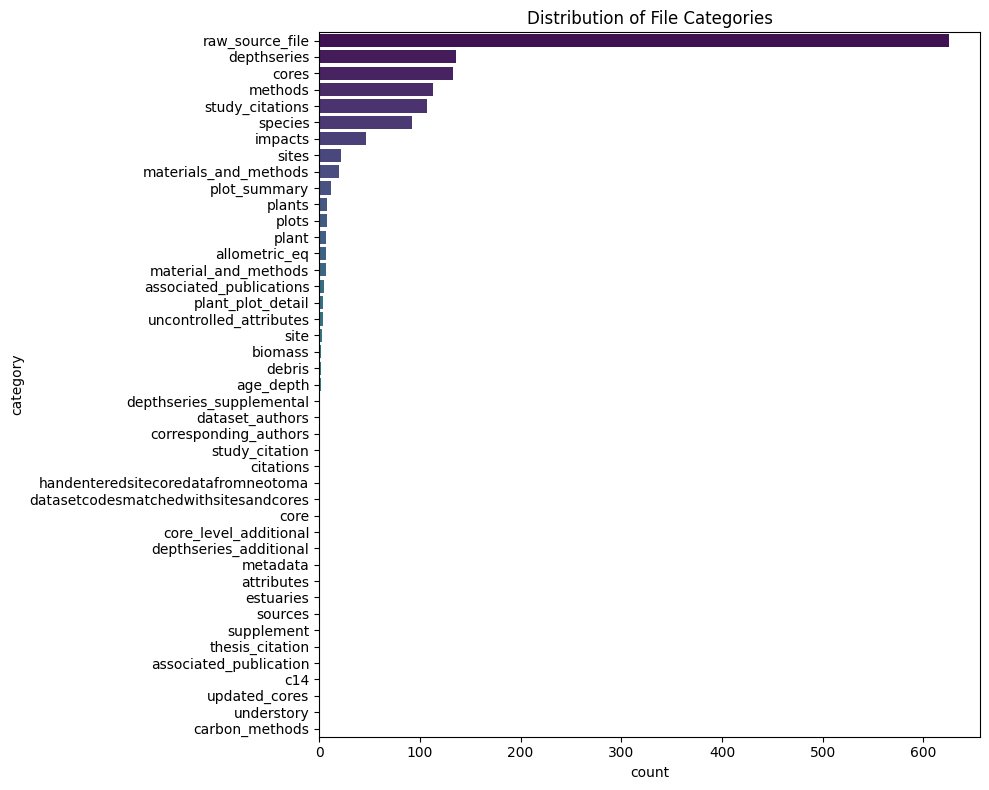

/var/folders/z8/q_52ss_56r1_77rxql_f1zkm0000gn/T/ipykernel_96101/906497354.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=study_counts.index, y=study_counts.values, palette="mako")


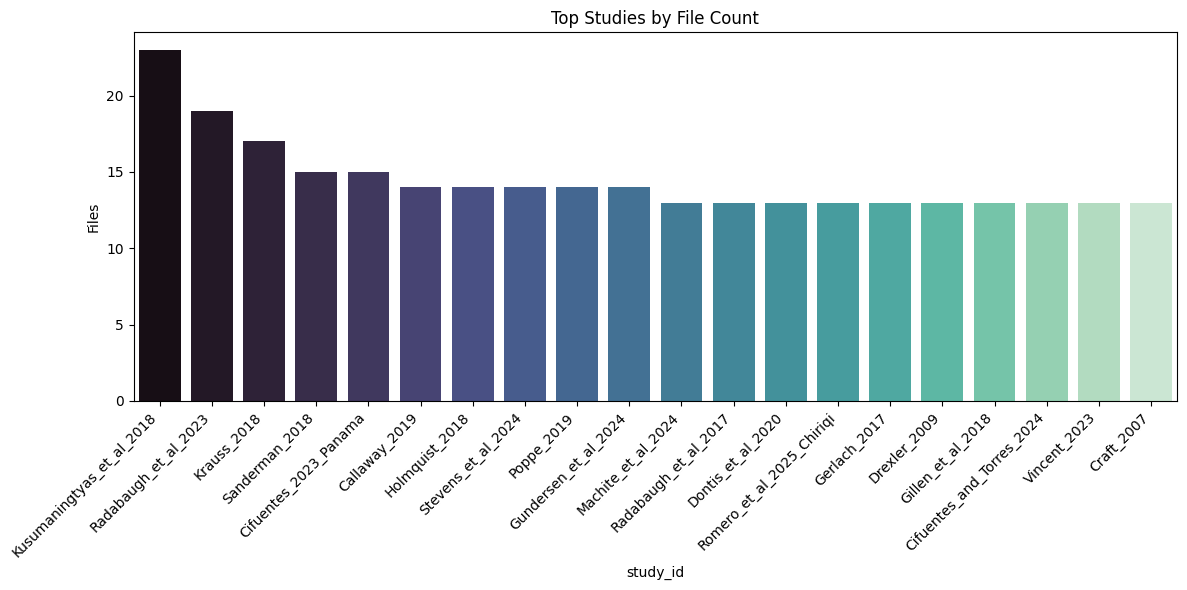

In [3]:
# Inventory all study files
inventory = []
all_files = list(DATA_ROOT.rglob("*"))

for f in all_files:
    info = parse_file_info(f)
    if info:
        inventory.append(info)

df_inv = pd.DataFrame(inventory)
print(f"Found {len(df_inv)} valid data files.")
display(df_inv.head())

# Category distribution
plt.figure(figsize=(10, 8))
order = df_inv["category"].value_counts().index
sns.countplot(y="category", data=df_inv, order=order, palette="viridis")
plt.title("Distribution of File Categories")
plt.tight_layout()
plt.show()

# Study contribution by file counts
study_counts = df_inv["study_id"].value_counts().head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=study_counts.index, y=study_counts.values, palette="mako")
plt.title("Top Studies by File Count")
plt.ylabel("Files")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Identifying Files with SOM & Bulk Density Data

This cell filters the inventory down to the target processing stage and scans each file's column headers to find datasets that contain both soil organic matter (SOM) and bulk density measurements. Files missing either variable are excluded. The result is a shortlist of candidate files that have what's needed for further analysis.


In [9]:
# Pulling from studies instead of global dataset
study_files = df_inv[df_inv["stage"] == TARGET_STAGE].copy()
print(f"Using {len(study_files)} files from stage: {TARGET_STAGE}")

# Identify candidate files containing SOM and bulk density
candidate_files = []
for _, row in study_files.iterrows():
    try:
        if row["ext"] == ".csv":
            cols = pd.read_csv(row["path"], nrows=0).columns.tolist()
        elif row["ext"] in {".xlsx", ".xls"}:
            cols = pd.read_excel(row["path"], nrows=0).columns.tolist()
        elif row["ext"] == ".parquet":
            cols = pd.read_parquet(row["path"]).columns.tolist()
        else:
            continue
    except Exception:
        continue

    som_col = find_best_column(
        cols, candidates=None, keywords=SOM_KEYWORDS, bad_keywords=SOM_BAD_KEYWORDS, preferred=SOM_PREFERRED
    )
    bd_col = find_best_column(cols, BD_CANDIDATES)
    if som_col and bd_col:
        candidate_files.append(
            {
                "path": row["path"],
                "study_id": row["study_id"],
                "som_col": som_col,
                "bd_col": bd_col,
            }
        )

df_candidates = pd.DataFrame(candidate_files)
print(f"Found {len(df_candidates)} study files with SOM and bulk density columns.")
display(df_candidates)

Using 714 files from stage: derivative
Found 204 study files with SOM and bulk density columns.


,path,study_id,som_col,bd_col
0,../../../../data/primary_studies/Giblin_2018/d...,Giblin_2018,fraction_carbon,dry_bulk_density
1,../../../../data/primary_studies/Giblin_2018/d...,Giblin_2018,carbon_measured_or_modeled,dry_bulk_density_temperature
2,../../../../data/primary_studies/Thom_2019/der...,Thom_2019,fraction_organic_matter,dry_bulk_density
3,../../../../data/primary_studies/Miller_et_al_...,Miller_et_al_2022,carbon_measured_or_modeled,dry_bulk_density_temperature
4,../../../../data/primary_studies/Miller_et_al_...,Miller_et_al_2022,fraction_organic_matter,dry_bulk_density
...,...,...,...,...
199,../../../../data/primary_studies/Fourqurean_20...,Fourqurean_2012,fraction_carbon,dry_bulk_density
200,../../../../data/primary_studies/Sanderman_201...,Sanderman_2018,fraction_carbon,dry_bulk_density
201,../../../../data/primary_studies/Allen_et_al_2...,Allen_et_al_2022,fraction_organic_matter,dry_bulk_density
202,../../../../data/primary_studies/Buffington_et...,Buffington_et_al_2020,fraction_organic_matter,dry_bulk_density


# Loading & Combining SOM and Bulk Density Data

This cell loads the actual data from each candidate file and combines it into a single unified table. During loading, SOM and bulk density columns are standardized to consistent names regardless of how they were labeled in the original file, and geographic area information is pulled in where available. The result is one merged dataset ready for analysis, with each row traceable back to its source study.


In [ ]:
def load_som_bd_from_file(path, som_col, bd_col, study_id):
    # Load file into a DataFrame based on its format
    try:
        if path.endswith(".csv"):
            df = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
        elif path.endswith((".xlsx", ".xls")):
            df = pd.read_excel(path)
        elif path.endswith(".parquet"):
            df = pd.read_parquet(path)
        else:
            return None
    except Exception:
        return None

    # Standardize SOM and bulk densitycolumn names and convert to numeric values
    som_label = str(som_col)
    df = df.rename(columns={som_col: "som", bd_col: "bulk_density"})
    df["som"] = pd.to_numeric(df["som"], errors="coerce")
    df["bulk_density"] = pd.to_numeric(df["bulk_density"], errors="coerce")
    df["som_source"] = som_label  # preserving original column name for traceability
    df["source_study"] = study_id

    # Include geographiv area column if it can be identified
    area_col = find_best_column(df.columns, AREA_CANDIDATES)
    if area_col and area_col not in {"som", "bulk_density"}:
        df["area"] = df[area_col]

    cols = ["som", "bulk_density", "source_study", "som_source"]
    if "area" in df.columns:
        cols.append("area")
    return df[cols]


# Load and combine SOM - BD data from all the candidate files
som_bd_frames = []
for _, row in df_candidates.iterrows():
    df_part = load_som_bd_from_file(row["path"], row["som_col"], row["bd_col"], row["study_id"])
    if df_part is not None and not df_part.empty:
        som_bd_frames.append(df_part)

# Combine all the DataFrames into a single dataset - if nothing is loaded, it will return an empty DataFrame
if som_bd_frames:
    som_bd_df = pd.concat(som_bd_frames, ignore_index=True)
else:
    som_bd_df = pd.DataFrame(columns=["som", "bulk_density", "source_study"])

print("Total SOM-BD records:", len(som_bd_df))
display(som_bd_df.head())

Total SOM-BD records: 108200


,som,bulk_density,source_study,som_source,area
0,0.1327,0.19,Giblin_2018,fraction_carbon,Nelson_Island_Creek
1,0.1683,0.22,Giblin_2018,fraction_carbon,Nelson_Island_Creek
2,0.1661,0.23,Giblin_2018,fraction_carbon,Nelson_Island_Creek
3,0.1658,0.22,Giblin_2018,fraction_carbon,Nelson_Island_Creek
4,0.1784,0.22,Giblin_2018,fraction_carbon,Nelson_Island_Creek


# SOM vs Bulk Density Visualizations

This cell generates scatter plots exploring the relationship between soil organic matter and bulk density, both per study and across all studies combined. Individual per-study plots are saved to a local output folder for reference, and a kernel density estimate (KDE) plot is produced for the top contributing studies to show where data is most densely concentrated.


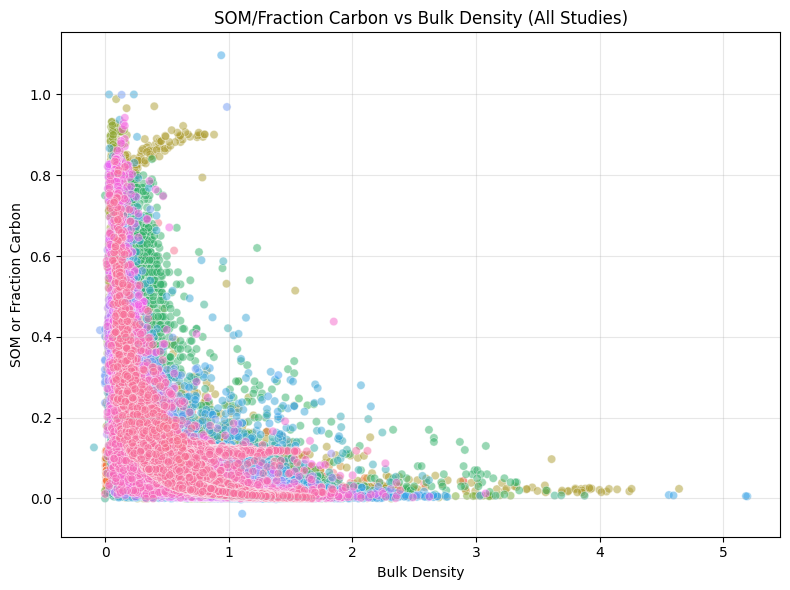

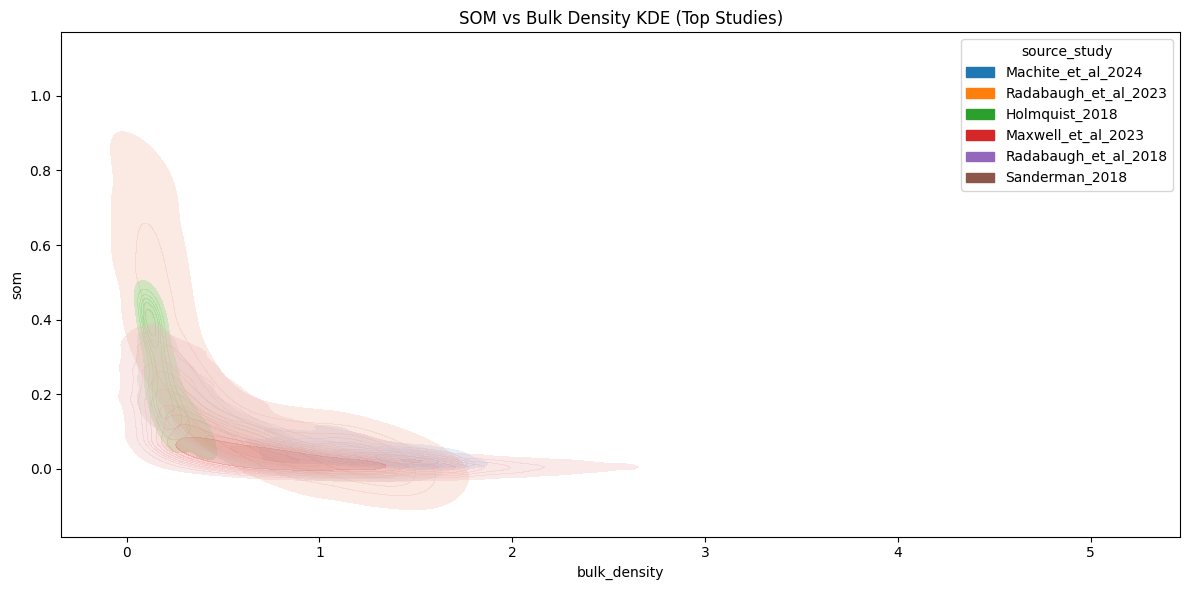

In [ ]:
# Distribution plots for soil organic matter vs bulk density
from pathlib import Path

if not som_bd_df.empty:
    out_dir = Path("SOM vs Bulk Density Plots")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Individual plot per study
    for study_name, sdf in som_bd_df.groupby("source_study"):
        if sdf.empty:
            continue
        som_label_raw = sdf["som_source"].dropna().unique()
        som_label_raw = som_label_raw[0] if len(som_label_raw) > 0 else "som"
        # Use original column name for label (title-cased)
        som_label = str(som_label_raw).replace("_", " ").title()

        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=sdf, x="bulk_density", y="som", alpha=0.6)
        plt.title(f"{som_label} vs Bulk Density {study_name}")
        plt.xlabel("Bulk Density")
        plt.ylabel(som_label)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        # Safe filename
        safe = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in str(study_name)).strip()
        plt.savefig(out_dir / f"SOM_vs_Bulk_Density_{safe}.png", dpi=150)
        plt.close()

    # Optional overview scatter (all studies)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=som_bd_df, x="bulk_density", y="som", hue="source_study", alpha=0.5, legend=False)
    plt.title("SOM/Fraction Carbon vs Bulk Density (All Studies)")
    plt.xlabel("Bulk Density")
    plt.ylabel("SOM or Fraction Carbon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Per-study distribution for top contributors (KDE)
    top_studies = som_bd_df["source_study"].value_counts().head(6).index.tolist()
    plt.figure(figsize=(12, 6))
    try:
        sns.kdeplot(
            data=som_bd_df[som_bd_df["source_study"].isin(top_studies)],
            x="bulk_density",
            y="som",
            hue="source_study",
            fill=True,
            alpha=0.3,
        )
        plt.title("SOM vs Bulk Density KDE (Top Studies)")
        plt.tight_layout()
        plt.show()
    except FloatingPointError:
        print("KDE plot skipped due to numerical underflow.")
else:
    print("No SOM vs bulk density data found in study files.")

# Geographic Contribution of Data Points

This cell analyzes which geographic areas or studies contribute the most data points to the combined SOM and bulk density dataset. If an area column is available, it plots the top regions by record count; otherwise it falls back to showing contributions at the study level.


/var/folders/z8/q_52ss_56r1_77rxql_f1zkm0000gn/T/ipykernel_96101/3533074496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.index, y=area_counts.values, palette="mako")


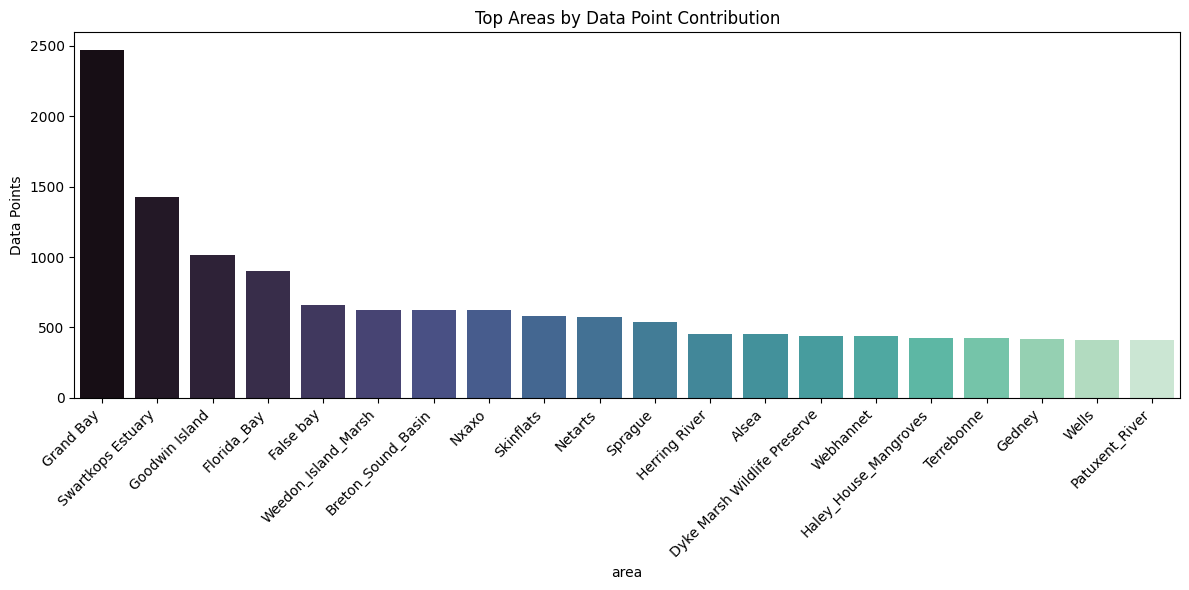

In [ ]:
# What geographical areas had more contribution (data points)
if not som_bd_df.empty:
    if "area" in som_bd_df.columns:
        area_counts = som_bd_df["area"].value_counts().head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=area_counts.index, y=area_counts.values, palette="mako")
        plt.title("Top Areas by Data Point Contribution")
        plt.ylabel("Data Points")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No area column found; showing study contributions instead.")
        study_counts = som_bd_df["source_study"].value_counts().head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=study_counts.index, y=study_counts.values, palette="mako")
        plt.title("Study Contributions by Data Points")
        plt.ylabel("Data Points")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No SOM-BD data to compute area contribution.")

# Global Exploratory Data Analysis

This cell provides a high-level statistical summary of the combined dataset across all studies, including descriptive statistics, distribution histograms for SOM and bulk density values, and a correlation heatmap to examine the relationship between the two variables.

,som,bulk_density
count,71237.000000,92961.000000
mean,0.118487,0.711576
std,0.151701,2.802553
min,-0.037948,-81.150000
25%,0.022300,0.243767
50%,0.059852,0.509893
75%,0.148610,0.892000
max,1.097000,110.000000


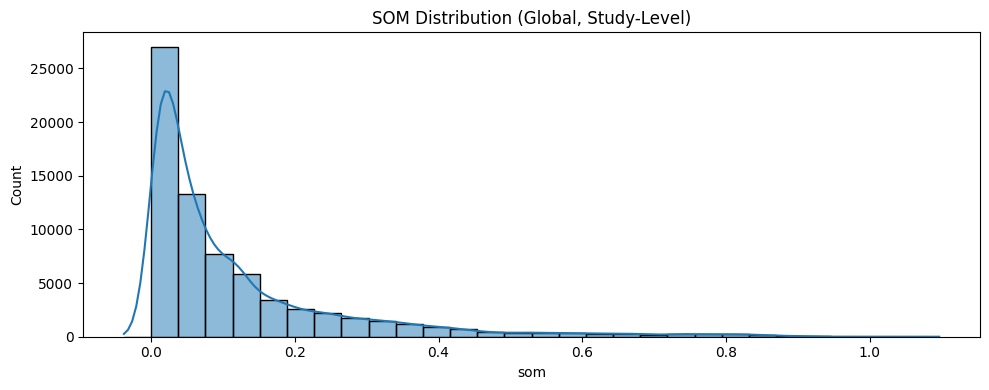

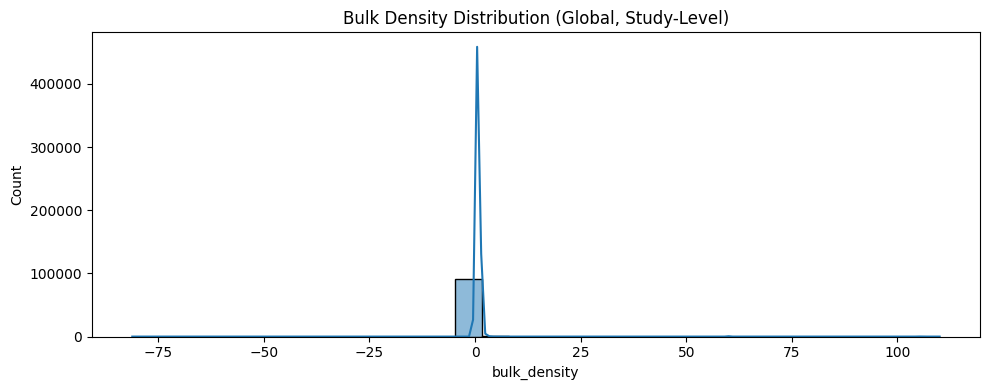

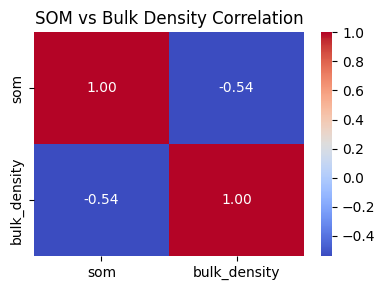

In [12]:
# Global EDA analysis

if not som_bd_df.empty:
    display(som_bd_df[["som", "bulk_density"]].describe())

    plt.figure(figsize=(10, 4))
    sns.histplot(som_bd_df["som"], bins=30, kde=True)
    plt.title("SOM Distribution (Global, Study-Level)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.histplot(som_bd_df["bulk_density"], bins=30, kde=True)
    plt.title("Bulk Density Distribution (Global, Study-Level)")
    plt.tight_layout()
    plt.show()

    corr = som_bd_df[["som", "bulk_density"]].corr()
    plt.figure(figsize=(4, 3))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("SOM vs Bulk Density Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("Global EDA skipped: no SOM-BD data available.")